In [1]:
import pandas as pd

# Load dataset
df = pd.read_csv("students.csv")

print("First 5 rows:")
print(df.head())

print("\nShape of dataset:", df.shape)

print("\nData types:")
print(df.dtypes)

print("\nSummary statistics:")
print(df.describe())

print("\nPass/Fail count:")
print(df['passed'].value_counts())

subject_cols = ['math', 'science', 'english', 'history', 'pe']

print("\nAverage marks for PASS students:")
print(df[df['passed'] == 1][subject_cols].mean())

print("\nAverage marks for FAIL students:")
print(df[df['passed'] == 0][subject_cols].mean())

df['overall_avg'] = df[subject_cols].mean(axis=1)

top_student = df.loc[df['overall_avg'].idxmax()]

print("\nTop student:")
print(top_student['name'], "-", round(top_student['overall_avg'], 2))

First 5 rows:
      name  math  science  english  history  pe  attendance_pct  \
0    Alice    88       92       76       80  95              92   
1      Bob    42       55       48       50  60              65   
2  Charlie    75       70       80       68  88              85   
3    Diana    95       98       91       89  97              98   
4      Eve    38       42       50       45  55              58   

   study_hours_per_day  passed  
0                  4.5       1  
1                  1.2       0  
2                  3.0       1  
3                  6.0       1  
4                  0.8       0  

Shape of dataset: (15, 9)

Data types:
name                    object
math                     int64
science                  int64
english                  int64
history                  int64
pe                       int64
attendance_pct           int64
study_hours_per_day    float64
passed                   int64
dtype: object

Summary statistics:
            math    science    

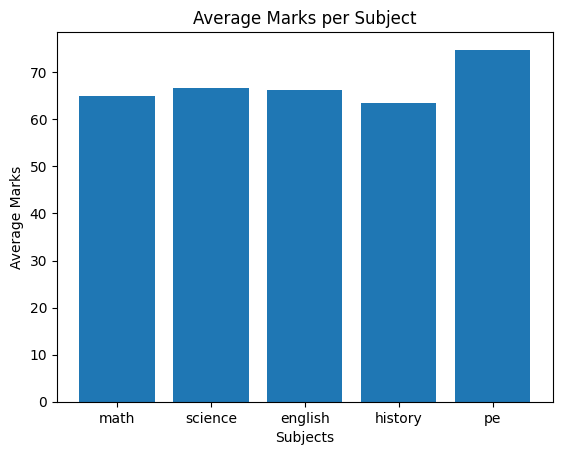

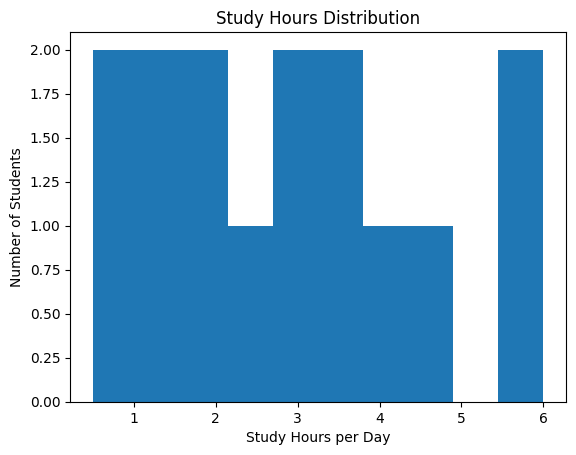

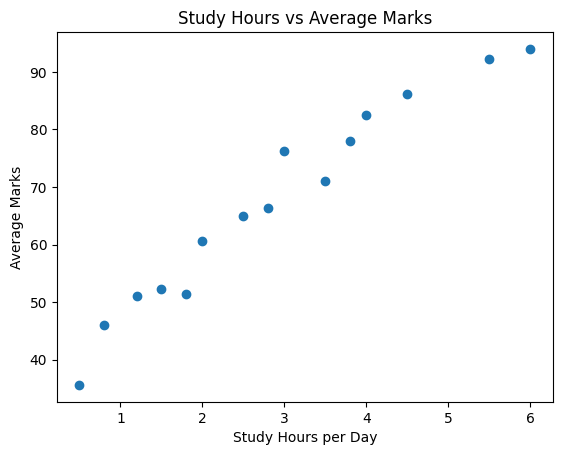

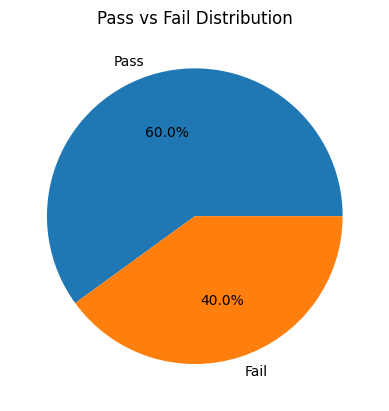

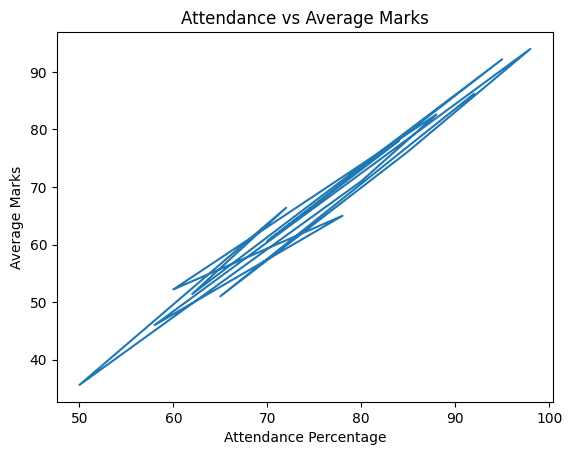

In [2]:
import matplotlib.pyplot as plt

# 1. Bar chart — Average marks per subject
subject_cols = ['math', 'science', 'english', 'history', 'pe']
avg_marks = df[subject_cols].mean()

plt.figure()
plt.bar(subject_cols, avg_marks)
plt.title("Average Marks per Subject")
plt.xlabel("Subjects")
plt.ylabel("Average Marks")
plt.show()


# 2. Histogram — Study hours distribution
plt.figure()
plt.hist(df['study_hours_per_day'])
plt.title("Study Hours Distribution")
plt.xlabel("Study Hours per Day")
plt.ylabel("Number of Students")
plt.show()


# 3. Scatter plot — Study hours vs Final Average
plt.figure()
plt.scatter(df['study_hours_per_day'], df['overall_avg'])
plt.title("Study Hours vs Average Marks")
plt.xlabel("Study Hours per Day")
plt.ylabel("Average Marks")
plt.show()


# 4. Pie chart — Pass vs Fail
pass_fail_counts = df['passed'].value_counts()

plt.figure()
plt.pie(pass_fail_counts, labels=["Pass", "Fail"], autopct='%1.1f%%')
plt.title("Pass vs Fail Distribution")
plt.show()


# 5. Line chart — Attendance vs Average Marks
plt.figure()
plt.plot(df['attendance_pct'], df['overall_avg'])
plt.title("Attendance vs Average Marks")
plt.xlabel("Attendance Percentage")
plt.ylabel("Average Marks")
plt.show()

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

# Features and target
features = ['math', 'science', 'english', 'history', 'pe', 'attendance_pct', 'study_hours_per_day']
X = df[features]
y = df['passed']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model
model = LogisticRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy:", accuracy)

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Model Accuracy: 1.0

Confusion Matrix:
[[2 0]
 [0 1]]


In [4]:
import pandas as pd

new_student = pd.DataFrame([[70, 75, 72, 68, 80, 85, 3.5]],
                           columns=['math', 'science', 'english', 'history', 'pe', 'attendance_pct', 'study_hours_per_day'])

prediction = model.predict(new_student)

if prediction[0] == 1:
    print("The student is predicted to PASS.")
else:
    print("The student is predicted to FAIL.")

The student is predicted to PASS.
